# 🔍 NLP Project: Intelligent Search Engine

## 0. imports and load data 

In [1]:
%pip install sentence_transformers streamlit symspellpy

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\program\python3.10\python.exe -m pip install --upgrade pip' command.


In [ ]:
# what is the deff between lemmatizer and stemming
# what is word2vector
# what is transformer embbiding
# what is TF and IDF ?
# how TF-IDF work ?
# what is percisio?
# which model retrive more relevant result?
# which model understand the meaning better?

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')


In [4]:
#load the data
data = pd.read_csv(r'Amazon_Reviews.csv',engine='python')
data.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


---
## 1. data preprocessing

In [5]:
data.drop(columns=['Reviewer Name','Profile Link','Country','Review Date','Rating','Review Count','Date of Experience'], inplace=True)
data.head()

,Review Title,Review Text
0,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ..."
1,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...
2,I informed these reprobates,I informed these reprobates that I WOULD NOT B...
3,Advertise one price then increase it on website,I have bought from Amazon before and no proble...
4,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...


In [6]:
#remove dublicated rows 
print("the duplicated rows are: {}".format(data.duplicated().sum()))
data.drop_duplicates(inplace=True)
print("the duplicated rows after dropping are: {}".format(data.duplicated().sum()))

#check for null values
print("\nthe null values are:\n {}".format(data.isnull().sum()))
data.dropna(inplace=True)
print("\nthe null values after dropping are:\n {}".format(data.isnull().sum()))

print("\nthe shape of the data is: {}".format(data.shape))

the duplicated rows are: 192
the duplicated rows after dropping are: 0

the null values are:
 Review Title    1
Review Text     1
dtype: int64

the null values after dropping are:
 Review Title    0
Review Text     0
dtype: int64

the shape of the data is: (21021, 2)


In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# to remove words like "the", "is", "in", etc.
stop_words = set(stopwords.words('english'))

# to reduce words to their root form ("running" to "run")
# lemmatization is more efficient than stemming
lemmatizer = WordNetLemmatizer()

def text_preprocessing(text):
    #lower case
    text = text.lower()

    # remove punctuation explicitly an special chararacters
    # shelna el arkam kmaan 34an kan fe kteeeer 3amel noise
    text = re.sub(r'[^a-z\s]', '', text)

    #tokenization
    text = nltk.word_tokenize(text)

    #stop words removal
    text = [t for t in text if t not in stop_words]

    #lemmatization
    text = [lemmatizer.lemmatize(t,) for t in text]
    return " ".join(text)


In [8]:
# test the function on a sample review
text_preprocessing(""" The delivery was extremely slow and the package arrived late """)

'delivery extremely slow package arrived late'

In [9]:
#this is for TF-IDF vectorizer
data['processed'] = data['Review Text'].apply(text_preprocessing)
data.head()

,Review Title,Review Text,processed
0,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...",registered website tried order laptop entered ...
1,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,multiple order one turned driver phone door nu...
2,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,informed reprobate would going visit sick rela...
3,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,bought amazon problem happy service price amaz...
4,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,could give lower rate would cancelled amazon p...


---
## 2. Feature Extraction 

### A. TF-IDF 

> **TF-IDF** measures how important a word is in a document **relative to the whole corpus**.  
> - **TF**: How often the word appears in the document.  
> - **IDF**: Penalizes words that appear in many documents (common = less useful).

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

docs_tfidf = data['processed']

#convert the documents to a matrix of TF-IDF features
# min_df=5 → removes words apear less than 5 times
# max_df=0.8 → removes overly common words (is,the...)
tfidf = TfidfVectorizer(max_features=5000,  min_df=5, max_df=0.8)
tfidf_matrix = tfidf.fit_transform(docs_tfidf)

print("the shape of the tfidf matrix is: {}".format(tfidf_matrix.shape))
print(f'   • {tfidf_matrix.shape[0]} documents × {tfidf_matrix.shape[1]} unique terms')

# to view sample of vocab
vocab = tfidf.get_feature_names_out()
print(f'   • sample vocab 10 terms: {list(vocab[:10])}')

the shape of the tfidf matrix is: (21021, 5000)
   • 21021 documents × 5000 unique terms
   • sample vocab 10 terms: ['abandoned', 'ability', 'able', 'abroad', 'abrupt', 'abruptly', 'absolute', 'absolutely', 'absurd', 'abuse']


### B. BERT

In [11]:
from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer('all-MiniLM-L6-v2')
sentence_embeddings = bert_model.encode(data['Review Text'].tolist())

print("the shape of the sentence embeddings is: {}".format(sentence_embeddings.shape))

print(f'   • BERT Embedding Matrix Shape : {sentence_embeddings.shape}')
print(f'   • {sentence_embeddings.shape[0]} documents × {sentence_embeddings.shape[1]} dimensions')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8463.55it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


the shape of the sentence embeddings is: (21021, 384)
   • BERT Embedding Matrix Shape : (21021, 384)
   • 21021 documents × 384 dimensions


In [12]:
sentence_embeddings

array([[-0.06410868,  0.0149195 ,  0.01709846, ..., -0.08020496,
         0.01218919,  0.01407036],
       [-0.01372676,  0.02586569,  0.01408728, ..., -0.00937259,
         0.02128766,  0.0208873 ],
       [-0.03447383,  0.01851436,  0.01274854, ...,  0.01132601,
        -0.0277549 , -0.05090376],
       ...,
       [-0.019634  , -0.11073776,  0.02241957, ..., -0.12828842,
        -0.01426825,  0.06795835],
       [-0.01684476,  0.02261029,  0.00884647, ..., -0.063455  ,
        -0.0300347 ,  0.06684287],
       [-0.03359522, -0.01883346,  0.08433177, ..., -0.10244994,
        -0.00876144,  0.06785824]], shape=(21021, 384), dtype=float32)

---
## 3. baseline model(tfidf+ cosine similarity)


**how it work?**
1. Preprocess the user query
2. Transform it into a TF-IDF vector
3. Compute cosine similarity against all document vectors
4. Return Top-k most similar documents

 **Limitation**: Can only match on exact keywords — misses synonyms and paraphrases.

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

def search_tfidf(query, k, view):

    processed_query = text_preprocessing(query)

    query_vec = tfidf.transform([processed_query])

    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten() #flatten to convert it to list[] not arrray[[]]

    #return the index of the top k similar documents assinding
    top_k_idx = similarities.argsort()[-k:][::-1]
    result = data.iloc[top_k_idx][['Review Title', 'Review Text']].copy()
    result['Similarity Score'] = similarities[top_k_idx]

    if view:
        print(f'\n⭕ [baseline — TF-IDF] query: "{query}"')
        print(f'processed: "{processed_query}"')
        print('   ' + '─'*65)

        for _, row in result.iterrows():
            print(f"Review Title: {row['Review Title']}")
            print(f"Review Text: {row['Review Text']}")
            print(f"Similarity Score: {row['Similarity Score']:.4f}")
            print("-" * 50)

    return result


In [14]:
search_tfidf("delivery problem",5, view=False)

,Review Title,Review Text,Similarity Score
20058,good srvice quick deliverys,no problems here,0.807344
15505,I have no problems with the service I…,I have no problems with the service I have,0.692869
3530,very bad service,very bad serviceevery time there is a problem ...,0.682395
20351,excellent,never had any problems with deliveries and alw...,0.641831
20301,Amazon Rocks,Have never had a problem with them,0.622072


---
## 4. advanced model(semantic search + bert)

**how it work?**
1. Transform it using 
2. Compute cosine similarity against all document vectors
3. Return Top-k most similar documents

In [15]:
def search_bert(query, k, view: bool = True):
    query_vec = bert_model.encode([query])

    similarities = cosine_similarity(query_vec, sentence_embeddings).flatten()

    top_k_idx = similarities.argsort()[-k:][::-1]

    result = data.iloc[top_k_idx][['Review Title', 'Review Text']].copy()
    result['Similarity Score'] = similarities[top_k_idx]

    if view:
        print(f'\n⭕ [advanced — BERT] query: "{query}"')
        print(f'processed: "{text_preprocessing(query)}"')
        print('   ' + '─'*65)

        for _, row in result.iterrows():
            print(f"Review Title: {row['Review Title']}")
            print(f"Review Text: {row['Review Text']}")
            print(f"Similarity Score: {row['Similarity Score']:.4f}")
            print("-" * 50)

    return result

In [16]:
search_bert("delivery problem",5, view=False)

,Review Title,Review Text,Similarity Score
582,Horrible delivery service,Horrible delivery service,0.759596
8132,Very bad delivery service Delivery…,Very bad delivery service Delivery attempt 3-4...,0.749848
3530,very bad service,very bad serviceevery time there is a problem ...,0.722301
15172,Some delivery’s never come and some…,Some delivery’s never come and some delivery’s...,0.716700
6691,order not dispatched,"order not dispatched, very bad delivery time",0.689884


---
## 5.Evaluation 
#### 1.Side-by-Side Comparison

In [17]:
import time
test_deff_query = [
    "delivery problem ",
    "item quality issue",
    "cannot get help from support",
    "payment charge error" ]

print("\t\tcomparison of results for different queries")

for q in test_deff_query:

    print(f"\n🔍 Query: {q}")
    print("   " + "─"*40)

    start = time.time()
    result_tfidf = search_tfidf(q,3, view=False)
    end = time.time()
    tim_tfidf = end - start

    start = time.time()
    result_bert = search_bert(q,3, view=False)
    end = time.time()
    tim_bert = end - start

    tfidf_header = f"⭕ TF-IDF (baseline) time = {tim_tfidf:.4f}"
    bert_header = f"🟢 BERT (advanced) time = {tim_bert:.4f}"

    print(f"  {tfidf_header:<38}  {bert_header}")
    print(f'{"  " + "─"*36:<40} {"─"*36}')
    for i in range(3):
        #title, review, score
        t, t_text, t_score = result_tfidf.iloc[i]
        b, b_text, b_score = result_bert.iloc[i]

        t_short = t_text[:33] + '...' if len(t_text) > 36 else t_text
        b_short = b_text[:33] + '...' if len(b_text) > 36 else b_text
        # build the whole left side as one string
        left_col = f"[{t}] {t_short}"

        # make it to never exceed 40 char
        if len(left_col) > 40:
            left_col = left_col[:37] + "..."

        print(f'{left_col:<40}  [{b}] {b_short}')

		comparison of results for different queries

🔍 Query: delivery problem 
   ────────────────────────────────────────
  ⭕ TF-IDF (baseline) time = 0.0160       🟢 BERT (advanced) time = 0.0339
  ────────────────────────────────────   ────────────────────────────────────
[good srvice quick deliverys] no prob...  [Horrible delivery service] Horrible delivery service 
[I have no problems  with the service...  [Very bad delivery service Delivery…] Very bad delivery service Deliver...
[very bad service] very bad serviceev...  [very bad service] very bad serviceevery time there ...

🔍 Query: item quality issue
   ────────────────────────────────────────
  ⭕ TF-IDF (baseline) time = 0.0217       🟢 BERT (advanced) time = 0.0281
  ────────────────────────────────────   ────────────────────────────────────
[My go to place to shop online.] Have...  [Amazon apparently does not care about quality…] Amazon apparently does not care a...
[Fantastic] All the items are in good...  [Generally most items q

#### 2. precision@k 


**Precision@k** measures how many of the Top-k returned documents are actually relevant.

$$\text{Precision@k} = \frac{\text{Number of relevant documents in Top-k}}{k}$$

We perform **manual relevance annotation** for each test query.

In [18]:
# ## el goz2 dah 3rfna beeh bs el index elsa7

# for q in test_deff_query:
#     # Run the search for the query
#     tfidf_res = search_tfidf(q, 5, view=False)
#     bert_res = search_bert(q, 5, view=False)

#     # Combine the indices from both models and remove any duplicates
#     combined_indices = list(set(tfidf_res.index.tolist() + bert_res.index.tolist()))

#     # Print the full text for each index
#     print(f"🔍 Full Review Texts for query: '{q}'\n" + "="*80)
#     for idx in combined_indices:
#         # Identify which model returned this index
#         found_in = []
#         if idx in tfidf_res.index: found_in.append("TF-IDF")
#         if idx in bert_res.index: found_in.append("BERT")

#         print(f"📌 Index {idx} | Found in: {' & '.join(found_in)}")
#         print(f"Review Text:\n{data.loc[idx, 'Review Text']}")
#         print("-" * 80)
#     print("="*30 + "\n\n")

In [19]:
# 5aly balk ehna hena 3mlinha manual
# y3ni 34an mi4 3rfin el actual label lkol relavent review
# fa hn4of el output b3daha n3rf eh el index ele tl3 we n7oto 

K = 5
# manual relevance checking
ground_truth = {
    "delivery problem": [582,8132,3530,15172,6691],
    "item quality issue": [10750,10752,4714,17151],
    "cannot get help from support": [5939,17461,9365,18132 ,13304],
    "payment charge error": [6710, 3787, 1042, 4069, 2089, 12108,541,8582]
}

def precision_at_k(retrieved_indices, relevant_indices, k):
    """calculates precision@k = (Number of relevant documents in Top-k) / k"""
    if not relevant_indices:
        return 0.0
    hits = sum(1 for idx in retrieved_indices[:k] if idx in relevant_indices)
    return hits / k

print(f'📊 EVALUATION RESULTS — Precision@{K}')
print('=' * 65)

# to save the results to visiualize it later
tfidf_precisions = []
bert_precisions = []
query_labels = []

test_deff_query = list(ground_truth.keys())

for query in test_deff_query:
    #actual label
    relevant_docs_id = ground_truth.get(query, [])

    #retrieve top-K results
    tfidf_res = search_tfidf(query, K, view=False)
    bert_res  = search_bert(query, K, view=False)

    #get the index frfrom prediction
    tfidf_indices = tfidf_res.index.tolist()
    bert_indices  = bert_res.index.tolist()

    # calculate precision
    p_tfidf = precision_at_k(tfidf_indices, relevant_docs_id, K)
    p_bert  = precision_at_k(bert_indices, relevant_docs_id, K)

    # save the precision for plotting later
    tfidf_precisions.append(p_tfidf)
    bert_precisions.append(p_bert)
    query_labels.append(query)

    print(f"\n📌 Query: '{query}'")
    print(f"   ⭕ TF-IDF Retrieved (Top-{K}): {tfidf_indices}")
    print(f"   🟢 BERT Retrieved (Top-{K})  : {bert_indices}")
    print(f"   • TF-IDF Precision@{K} = {p_tfidf:.2f} ({int(p_tfidf*K)}/{K} relevant)")
    print(f"   • BERT Precision@{K}   = {p_bert:.2f} ({int(p_bert*K)}/{K} relevant)")

📊 EVALUATION RESULTS — Precision@5

📌 Query: 'delivery problem'
   ⭕ TF-IDF Retrieved (Top-5): [20058, 15505, 3530, 20351, 20301]
   🟢 BERT Retrieved (Top-5)  : [582, 8132, 3530, 15172, 6691]
   • TF-IDF Precision@5 = 0.20 (1/5 relevant)
   • BERT Precision@5   = 1.00 (5/5 relevant)

📌 Query: 'item quality issue'
   ⭕ TF-IDF Retrieved (Top-5): [19632, 20548, 16604, 10151, 18289]
   🟢 BERT Retrieved (Top-5)  : [10750, 10752, 4714, 19840, 17151]
   • TF-IDF Precision@5 = 0.00 (0/5 relevant)
   • BERT Precision@5   = 0.80 (4/5 relevant)

📌 Query: 'cannot get help from support'
   ⭕ TF-IDF Retrieved (Top-5): [21081, 14992, 18132, 9137, 13304]
   🟢 BERT Retrieved (Top-5)  : [5939, 17461, 8692, 20145, 9365]
   • TF-IDF Precision@5 = 0.40 (2/5 relevant)
   • BERT Precision@5   = 0.60 (3/5 relevant)

📌 Query: 'payment charge error'
   ⭕ TF-IDF Retrieved (Top-5): [541, 2971, 8582, 12108, 19567]
   🟢 BERT Retrieved (Top-5)  : [6710, 3787, 1042, 4069, 2089]
   • TF-IDF Precision@5 = 0.60 (3/5 rel

### 3.visiualization 

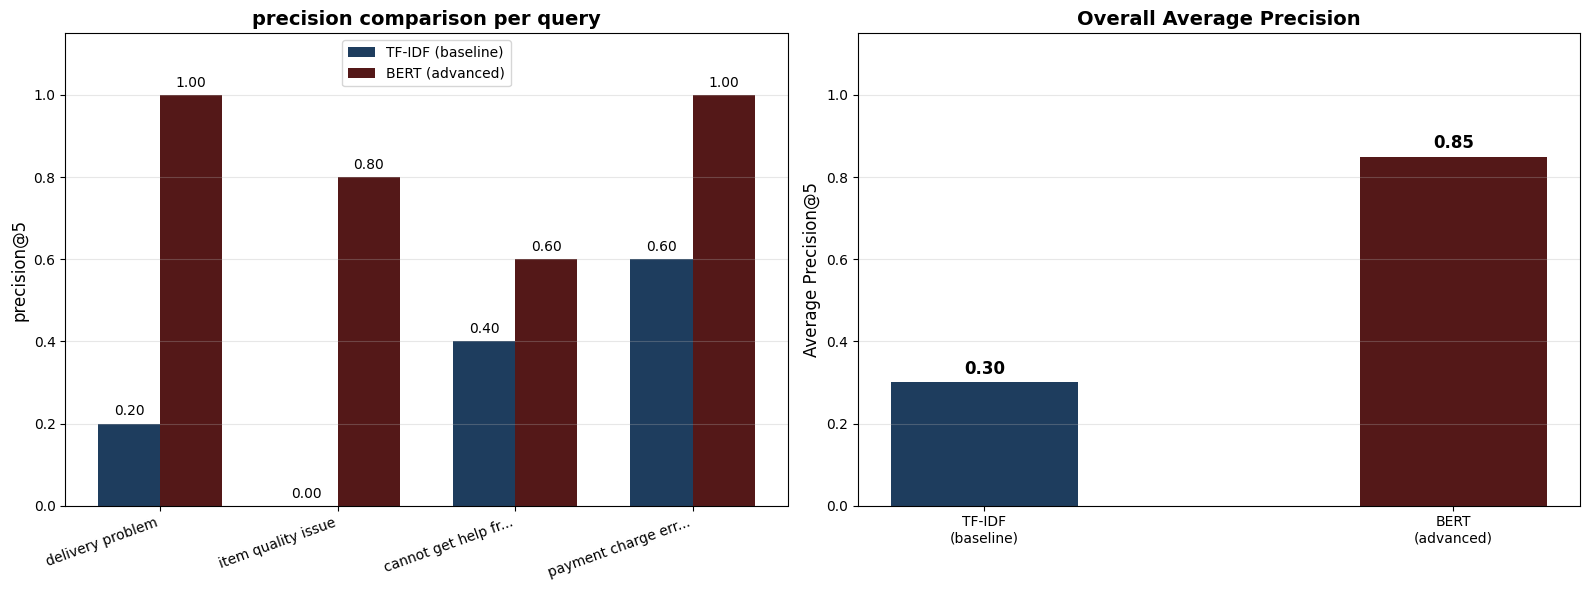

In [20]:
# Truncate query labels if they are too long for the x-axis
short_labels = [q[:18] + "..." if len(q)>18 else q for q in query_labels]

x = np.arange(len(query_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plot 1 precision of both models per query
bars1 = axes[0].bar(x - width/2, tfidf_precisions, width, label='TF-IDF (baseline)', color="#1E3D5E")
bars2 = axes[0].bar(x + width/2, bert_precisions, width, label='BERT (advanced)', color="#541818")

axes[0].set_ylabel(f'precision@{K}', fontsize=12)
axes[0].set_title('precision comparison per query', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_labels, rotation=20, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.15) # Leave room for value text
axes[0].grid(axis='y', alpha=0.3)

# Add text numbers on top of the bars
for i in range(len(query_labels)):
    axes[0].text(x[i] - width/2, tfidf_precisions[i] + 0.02, f'{tfidf_precisions[i]:.2f}', ha='center', fontsize=10)
    axes[0].text(x[i] + width/2, bert_precisions[i] + 0.02, f'{bert_precisions[i]:.2f}', ha='center', fontsize=10)

#------------------------------------------------
#plot2 overall (average) precision ---
avg_tfidf = np.mean(tfidf_precisions)
avg_bert = np.mean(bert_precisions)

models = ['TF-IDF\n(baseline)', 'BERT\n(advanced)']
avgs = [avg_tfidf, avg_bert]
colors = ['#1E3D5E', '#541818']

bars = axes[1].bar(models, avgs, color=colors, width=0.4)
axes[1].set_ylabel(f'Average Precision@{K}', fontsize=12)
axes[1].set_title('Overall Average Precision', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis='y', alpha=0.3)

# Add text numbers on top of the bars
for bar, avg in zip(bars, avgs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{avg:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 📝summary: baseline vs advanced model

while evaluating the search quality using the Top-5 results highlights the following comparison:

**1. which model retrieves more relevant results?**
* **🟢 BERT (advanced model)** retrieves a significantly higher number of relevant results. 
* **⭕ TF-IDF (Baseline)** struggles with relevance. like when querying *"item quality issue"*, TF-IDF returns positive reviews (e.g., *"All the items are in good quality..."*) simply because the exact words "item" and "quality" overlap. BERT successfully avoids these false positives and retrieves actual complaints (e.g., *"The quality is extremely poor"*).

**2. Which model understands meaning better?**
* **🟢 BERT** understands semantic meaning and context. When querying *"food delivery problem"*, BERT understands the negative sentiment and underlying context, retrieving results like *"Horrible delivery service"* without necessarily needing the exact keyword "problem".
* **⭕ TF-IDF** relies strictly on **Keyword Matching** and entirely misses the intent. For the query *"cannot get help from support"*, TF-IDF matches the word "help" and returns highly positive reviews (*"ALLWAYS THERE TO HELP"*). It fails to process the negation ("cannot") or the customer's actual complaint intent.

**Conclusion:**
The advanced BERT model is vastly superior for this Intelligent Search Engine because it evaluates the **semantic meaning and context** of queries. The TF-IDF baseline falls short because it rewards exact word matches regardless of the surrounding context, making it easily confused by negations and synonyms.

## 6.deployment

ezay hnslm el client el shoghl !!? ana 3ndy tare2tain 
*  1_ eni ab3tlo el soursce code we deh haga mi4 sa7
*  2_ ab3tlo dump file we deh m3ndaha eni b3ml encapsulation ll model bta3y  t5lih howa my3rf4 ay tafasil 3n shoghly 

<p> hena hnzwt hett spilling correction

In [21]:
import pickle

data.to_pickle('data.pkl')
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))
pickle.dump(tfidf_matrix, open('tfidf_matrix.pkl', 'wb'))
pickle.dump(sentence_embeddings, open('sentence_embeddings.pkl', 'wb'))

In [22]:
%%writefile ISE_application.py
# ehna hena bn3ml create l web application b streamlit 34an n3rf el model bta3na
# ehna hna5od el functions mn foo2 3alatol
import streamlit as st
import pandas as pd
import pickle
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
# Import SymSpell for blazing-fast text correction
from symspellpy import SymSpell
import pkg_resources

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def text_preprocessing(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = nltk.word_tokenize(text)
    text = [t for t in text if t not in stop_words]
    text = [lemmatizer.lemmatize(t) for t in text]
    return " ".join(text)

@st.cache_resource
def load_data_and_models():
    df = pd.read_pickle('data.pkl')
    vec = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))
    matrix = pickle.load(open('tfidf_matrix.pkl', 'rb'))
    bert = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = pickle.load(open('sentence_embeddings.pkl', 'rb'))

    # initialize symSpell dah zy kamos bngeb mno elkalam elsa7
    sym_spell = SymSpell(max_dictionary_edit_distance=2, # aksa 3dd a5ta2 ys77ha felklma
    prefix_length=7)
    dictionary_path = pkg_resources.resource_filename(
        "symspellpy", "frequency_dictionary_en_82_765.txt")
    sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)

    return df, vec, matrix, bert, embeddings, sym_spell

data, tfidf, tfidf_matrix, bert_model, sentence_embeddings, sym_spell = load_data_and_models()

def correct_query(query):
    # 34an ys77 kaza kelma m3 b3d we momken yjoin kalam zy canot->cannot
    suggestions = sym_spell.lookup_compound(query, max_edit_distance=2)
    # bnrg3 el e5tyar ele 3ndo a3la prob ts7i7 (awlhom)
    return suggestions[0].term if suggestions else query

def search_tfidf(query, k=5):
    processed_query = text_preprocessing(query)
    query_vec = tfidf.transform([processed_query])
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_k_idx = similarities.argsort()[-k:][::-1]
    result = data.iloc[top_k_idx][['Review Title', 'Review Text']].copy()
    result['Similarity Score'] = similarities[top_k_idx]
    return result

def search_bert(query, k=5):
    query_vec = bert_model.encode([query])
    similarities = cosine_similarity(query_vec, sentence_embeddings).flatten()
    top_k_idx = similarities.argsort()[-k:][::-1]
    result = data.iloc[top_k_idx][['Review Title', 'Review Text']].copy()
    result['Similarity Score'] = similarities[top_k_idx]
    return result

st.title("Intelligent Search Engine")

model_choice = st.radio("Choose Model:", ("TF-IDF", "BERT"))
raw_query = st.text_input("Enter your search query:")

if st.button("Search"):
    if raw_query:
        with st.spinner("Searching..."):
            # 1. Correct the query instantly
            corrected_query = correct_query(raw_query)
            # 2. Inform the user if a correction was made
            if corrected_query.lower() != raw_query.lower():
                st.info(f"Showing results for: **{corrected_query}** *(Original: {raw_query})*")
            # 3. Perform the search
            if model_choice == "TF-IDF":
                results = search_tfidf(corrected_query)
            else:
                results = search_bert(corrected_query)
            # 4. Display results
            for _, row in results.iterrows():
                st.subheader(row['Review Title'])
                st.write(row['Review Text'])
                st.caption(f"Similarity Score: {row['Similarity Score']:.4f}")
                st.divider()

Overwriting ISE_application.py


In [23]:
# delviry problm
# iteim qulity issui
# cannnot get hlp frm suport
# paymnt chrge eror

# credit paymnt issue

cd /d D:\khaled\projects\NLP_ intelligent search engine
streamlit run ISE_application.py
